In [1]:
from cmc_controllers.metrics import (
    compute_frequency_amplitude_fft,
    compute_neural_phase_lags,
    filter_signals,
)

In [2]:
path = "D:\\Computational_motor_control\\cmc-2026-students\\Project1\\Python\\cmc_project_pack\\models\\a2sw5_cycle_smoothed.csv"
import numpy as np
data = np.genfromtxt(path, delimiter=",", skip_header=1)

times = data[10:-10, 0]
joint_angles_deg = data[10:-10, 1:9]
joint_angles = np.deg2rad(joint_angles_deg)

smooth = filter_signals(times=times, signals=joint_angles)

freqs, _, amps = compute_frequency_amplitude_fft(
    times=times,
    smooth_signals=smooth,
)

inds = [[i, i + 1] for i in range(7)]
_, ipls = compute_neural_phase_lags(
    times=times,
    smooth_signals=smooth,
    freqs=freqs,
    inds_couples=inds,
)

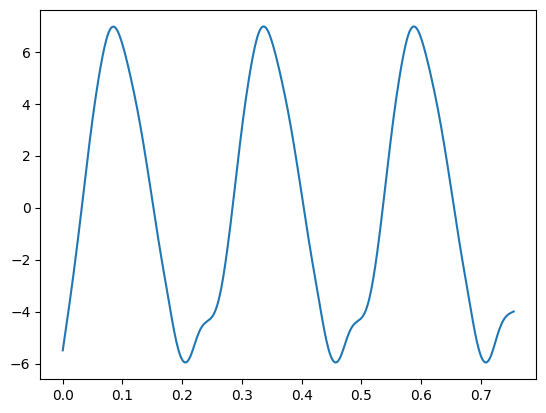

In [11]:
import matplotlib.pyplot as plt
time = data[:,0]
angle1 = data[:,1]
plt.plot(time, angle1)

In [12]:
#!/usr/bin/env python3

import os
import h5py
import matplotlib
matplotlib.use('Agg') # I added this
import matplotlib.pyplot as plt


from farms_core import pylog

from cmc_controllers.metrics import *
from simulate import runsim


BASE_PATH = 'logs/exercise2_3/'
PLOT_PATH = 'results'
ANIMAL_DATA_PATH = 'cmc_project_pack/models/a2sw5_cycle_smoothed.csv'
if os.path.basename(os.getcwd()).lower() == 'python':
    PLOT_PATH = os.path.join('..', PLOT_PATH)
os.makedirs(PLOT_PATH, exist_ok=True)

"""
def get_animal_data(path):
    #Load animal data
    data = np.genfromtxt(path, delimiter=',', skip_header=1)
    freq = np.zeros(8)
    amp = np.zeros(8)
    ipls = np.zeros(7)
    times = data[10:-10, 0]
    joint_angles = data[10:-10, 1:9]
    return freq, np.deg2rad(amp), ipls
"""
def get_animal_data(path):
    data = np.genfromtxt(path, delimiter=',', skip_header=1)

    times = data[10:-10, 0]
    joint_angles = data[10:-10, 1:9]

    # Smooth signals
    smooth = filter_signals(times=times, signals=joint_angles)

    # Frequency & amplitude
    freqs, _, amps = compute_frequency_amplitude_fft(
        times=times,
        smooth_signals=smooth,
    )

    # IPL (between adjacent joints)
    inds = [[i, i+1] for i in range(7)]
    _, ipls = compute_neural_phase_lags(
        times=times,
        smooth_signals=smooth,
        freqs=freqs,
        inds_couples=inds,
    )

    return freqs, amps, ipls

def exercise2_3(**kwargs):
    """ex2.3 main"""
    #pylog.warning("TODO: 2.3 Analyze the provided animal data and compare the animal locomotion performance with your implemented controller.")
    # pylog.set_level('critical')

    plot = kwargs.pop('plot', False)
    if plot:
        plt.show()


if __name__ == '__main__':
    exercise2_3(plot=True)

controller = {
    'loader': 'cmc_controllers.CPG_controller.CPGController',
    'config': {
        'drive_left': 3,
        'drive_right': 3,
        'd_low': 1,
        'd_high': 5,
        'a_rate': np.ones(8) * 3,
        'offset_freq': np.ones(8) * 1,
        'offset_amp': np.ones(8) * 0.5,
        'G_freq': np.ones(8) * 0.5,
        'G_amp': np.ones(8) * 0.25,
        'PL': float(2*np.pi/8),
        'coupling_weights_rostral': 5,
        'coupling_weights_caudal': 5,
        'coupling_weights_contra': 10,
        'init_phase': np.ascontiguousarray(
            np.random.uniform(0, 2*np.pi, 16)
        )
    }
}

runsim(
    controller=controller,
    base_path=BASE_PATH,
    headless=True,
    fast=True,
)

with h5py.File(BASE_PATH + "simulation.hdf5", "r") as f:
    times = f['times'][:]
    joints = f['FARMSLISTanimats']['0']['sensors']['joints']['array'][:, :, 0]
    


smooth = filter_signals(times=times, signals=joints)

freq_ctrl, _, amp_ctrl = compute_frequency_amplitude_fft(
    times=times,
    smooth_signals=smooth,
)

inds = [[i, i+1] for i in range(7)]
_, ipls_ctrl = compute_neural_phase_lags(
    times=times,
    smooth_signals=smooth,
    freqs=freq_ctrl,
    inds_couples=inds,
)

freq_animal, amp_animal, ipls_animal = get_animal_data(ANIMAL_DATA_PATH)

plt.figure()
plt.plot(freq_animal, 'o-', label='animal')
plt.plot(freq_ctrl, 's--', label='controller')
plt.title("Frequency comparison")
plt.xlabel("Joint index")
plt.ylabel("Frequency (Hz)")
plt.legend()
plt.savefig(os.path.join(PLOT_PATH, "freq.png"))

plt.figure()
plt.plot(amp_animal, 'o-', label='animal')
plt.plot(amp_ctrl, 's--', label='controller')
plt.title("Amplitude comparison")
plt.xlabel("Joint index")
plt.ylabel("Amplitude (rad)")
plt.legend()
plt.savefig(os.path.join(PLOT_PATH, "amp.png"))


plt.figure()
plt.plot(ipls_animal, 'o-', label='animal')
plt.plot(ipls_ctrl, 's--', label='controller')
plt.title("IPL comparison")
plt.xlabel("Segment")
plt.ylabel("Phase lag (rad)")
plt.legend()
plt.savefig(os.path.join(PLOT_PATH, "ipl.png"))

print("Saved plots to:", os.path.abspath(PLOT_PATH))
print("freq_ctrl:", freq_ctrl)
print("amp_ctrl:", amp_ctrl)
print("ipls_ctrl:", ipls_ctrl)

# [PYLOG-35916] 2026-04-12 13:26:34,093 - [INFO] - simulate.py::96::runsim()
# file:///d:/Computational_motor_control/cmc-2026-students/Project1/Python/simulate.py#L96
Loading options from clargs
-
# [PYLOG-35916] 2026-04-12 13:26:34,094 - [INFO] - simulation.py::51::setup_from_clargs()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_sim/farms_sim/simulation.py#L51
Getting experiment options
-
# [PYLOG-35916] 2026-04-12 13:26:34,194 - [INFO] - simulate.py::150::runsim()
# file:///d:/Computational_motor_control/cmc-2026-students/Project1/Python/simulate.py#L150
Creating simulation environment
-
# [PYLOG-35916] 2026-04-12 13:26:34,194 - [INFO] - simulation.py::147::run_simulation()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_sim/farms_sim/simulation.py#L147
Creating simulation
-
# [PYLOG-35916] 2026-04-12 13:26:34,201 - [INFO] - mjcf.py::272::mjc_add_link()
# file

  0%|          | 0/2501 [00:00<?, ?it/s]

# [PYLOG-35916] 2026-04-12 13:26:36,801 - [DEBUG] - task.py::145::initialize_episode()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_mujoco/farms_mujoco/simulation/task.py#L145
Initializing episode
-
# [PYLOG-35916] 2026-04-12 13:26:36,801 - [INFO] - physics.py::69::get_sensor_maps()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_mujoco/farms_mujoco/simulation/physics.py#L69
Sensors data:
FieldIndexer(sensordata):
  0              framelinvel_a0_Polymander_v6.2.1 [ 0       ]
  1              framelinvel_a0_Polymander_v6.2.1 [ 0       ]
  2              framelinvel_a0_Polymander_v6.2.1 [ 0       ]
  3              frameangvel_a0_Polymander_v6.2.1 [ 0       ]
  4              frameangvel_a0_Polymander_v6.2.1 [ 0       ]
  5              frameangvel_a0_Polymander_v6.2.1 [ 0       ]
  6                   framelinvel_a0_link_body_00 [ 0       ]
  7                   f

100%|█████████▉| 2493/2501 [00:04<00:00, 545.57it/s]

# [PYLOG-35916] 2026-04-12 13:26:41,448 - [INFO] - task.py::565::after_step()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_mujoco/farms_mujoco/simulation/task.py#L565
Simulation complete
-
# [PYLOG-35916] 2026-04-12 13:26:41,449 - [INFO] - task.py::569::after_step()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_mujoco/farms_mujoco/simulation/task.py#L569
Simulation can be restarted
-
# [PYLOG-35916] 2026-04-12 13:26:41,450 - [DEBUG] - task.py::613::get_termination()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_mujoco/farms_mujoco/simulation/task.py#L613
Termination activated (Reason: Final iteration)
-


100%|██████████| 2501/2501 [00:04<00:00, 538.05it/s]

# [PYLOG-35916] 2026-04-12 13:26:41,450 - [INFO] - extensions.py::127::end_episode()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_core/farms_core/simulation/extensions.py#L127
Saving data to logs/exercise2_3/
-
# [PYLOG-35916] 2026-04-12 13:26:41,451 - [INFO] - data.py::132::to_file()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_core/farms_core/experiment/data.py#L132
Exporting to dictionary
-
# [PYLOG-35916] 2026-04-12 13:26:41,456 - [INFO] - data.py::134::to_file()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_core/farms_core/experiment/data.py#L134
Saving data to logs/exercise2_3/simulation.hdf5
-


# [PYLOG-35916] 2026-04-12 13:26:41,766 - [INFO] - data.py::136::to_file()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_core/farms_core/experiment/data.py#L136
Saved data to logs/exercise2_3/simulation.hdf5
-
# [PYLOG-35916] 2026-04-12 13:26:41,767 - [INFO] - simulation.py::319::run()
# file:///D:/Computational_motor_control/cmc-2026-students/project_installation/cmc_project_pack/farms/farms_mujoco/farms_mujoco/simulation/simulation.py#L319
Closing simulation
-
# [PYLOG-35916] 2026-04-12 13:26:41,767 - [INFO] - simulate.py::158::runsim()
# file:///d:/Computational_motor_control/cmc-2026-students/Project1/Python/simulate.py#L158
Saving controller
-
freq_ctrl: [1.98670532 1.99295282 1.99295282 1.99920032 2.00544782 2.00544782
 2.00544782 2.00544782 0.0062475  0.0062475  0.0062475  0.0062475
 0.0062475  0.0062475  0.0062475  0.0062475  0.0062475  0.0062475 ]
amp_ctrl: [0.42635379 0.50432316 0.40634132 0.37924673 0.36859971 0.